# Cardiovascular Disease Prediction with Machine Learning

This project aims to predict the presence of cardiovascular diseases in patients using various health-related variables.

Several machine learning models were trained and evaluated, including:
- Logistic Regression
- Random Forest
- Gradient Boosting.

The models were compared using multiple evaluation metrics to determine which is the most suitable one for the task.

## Notebook Structure

1. [Data Loading](#data-loading)
2. [Data Exploration](#data-exploration)
3. [Data Cleaning and Wrangling](#data-cleaning-and-wrangling)
4. [Baseline Models](#baseline-models)
5. [Feature Engineering](#feature-engineering)
6. [Retraining](#retraining)
7. [Model Comparison](#model-comparison)
8. [Export for Visualization](#export-for-visualization)
9. [Conclusion](#conclusion)

# Data Loading

In [ ]:
!pip install kaggle

In [146]:
!kaggle datasets download sulianova/cardiovascular-disease-dataset

!unzip cardiovascular-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
License(s): unknown
cardiovascular-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  cardiovascular-disease-dataset.zip
replace cardio_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: cardio_train.csv        


In [145]:
import pandas as pd
df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# Data Exploration

In [8]:
# Check if there are missing values
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [9]:
# Quick overview of the data
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


# Data Cleaning and Wrangling

### Some key aspects about the data after some Google searches:
- Systolic blood pressure more often than not is lower than 200, even in people that have it really high
- Diastolic blood pressure more often than not is lower than 100, even if people that have it really high
- In a normal human being, systolic blood pressure is always higher than diastolic blood pressure

In [10]:
df["ap_lo"].describe()

,ap_lo
count,70000.000000
mean,96.630414
std,188.472530
min,-70.000000
25%,80.000000
50%,80.000000
75%,90.000000
max,11000.000000


In [11]:
print(f"Number of rows with abnormal ap_hi: {len(df.loc[(df['ap_hi'] > 240) | (df['ap_hi'] < 80)])}")
print(f"Number of rows with abnormal ap_lo: {len(df.loc[(df["ap_lo"] > 120) | (df["ap_lo"] < 40)])}")
print(f"Number of rows that are impossible: {len(df[df["ap_lo"] >= df["ap_hi"]])}")

Number of rows with abnormal ap_hi: 247
Number of rows with abnormal ap_lo: 1115
Number of rows that are impossible: 1236


<Axes: xlabel='ap_lo'>

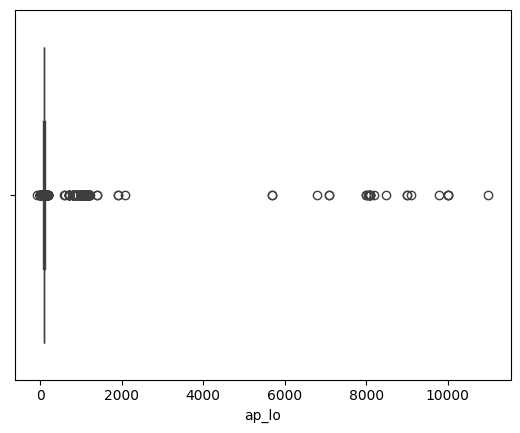

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using a boxplot as another way of checking for outliers

sns.boxplot(x=df["ap_lo"])

There are not that many rows with outliers and impossible values. Among the three types, there could also be overlapping rows from the results; even in the worst case, it would be 2598 rows, which is very little compared to the 70000 rows in the dataset.

As such, it is safe to get rid of them.

In [13]:
df = df[
    (df["ap_hi"] >= 80) &
    (df["ap_hi"] <= 240) &
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 150) &
    (df["ap_hi"] > df["ap_lo"])
]

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68662 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68662 non-null  int64  
 1   age          68662 non-null  int64  
 2   gender       68662 non-null  int64  
 3   height       68662 non-null  int64  
 4   weight       68662 non-null  float64
 5   ap_hi        68662 non-null  int64  
 6   ap_lo        68662 non-null  int64  
 7   cholesterol  68662 non-null  int64  
 8   gluc         68662 non-null  int64  
 9   smoke        68662 non-null  int64  
 10  alco         68662 non-null  int64  
 11  active       68662 non-null  int64  
 12  cardio       68662 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 7.3 MB


In [15]:
# Quick exploratory analysis with pairwise correlations
df.corr()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,1.000000,0.003632,0.003127,-0.002917,-0.002215,0.000830,-0.000392,0.005917,0.002321,-0.003818,0.000548,0.003507,0.003764
age,0.003632,1.000000,-0.023265,-0.081502,0.054586,0.209207,0.156316,0.155254,0.098805,-0.047650,-0.028893,-0.010176,0.239311
gender,0.003127,-0.023265,1.000000,0.499068,0.155996,0.062240,0.067635,-0.036815,-0.021163,0.338831,0.171350,0.005915,0.007042
height,-0.002917,-0.081502,0.499068,1.000000,0.291639,0.018509,0.036049,-0.050695,-0.018697,0.188323,0.094716,-0.007533,-0.010782
weight,-0.002215,0.054586,0.155996,0.291639,1.000000,0.271112,0.254159,0.141151,0.107075,0.067119,0.067501,-0.017772,0.179718
ap_hi,0.000830,0.209207,0.062240,0.018509,0.271112,1.000000,0.734536,0.195344,0.094313,0.027980,0.035815,-0.001189,0.428088
ap_lo,-0.000392,0.156316,0.067635,0.036049,0.254159,0.734536,1.000000,0.161633,0.074671,0.025615,0.037746,-0.000490,0.340747
cholesterol,0.005917,0.155254,-0.036815,-0.050695,0.141151,0.195344,0.161633,1.000000,0.450558,0.009813,0.034970,0.008583,0.221471
gluc,0.002321,0.098805,-0.021163,-0.018697,0.107075,0.094313,0.074671,0.450558,1.000000,-0.005845,0.010253,-0.007785,0.089689
smoke,-0.003818,-0.047650,0.338831,0.188323,0.067119,0.027980,0.025615,0.009813,-0.005845,1.000000,0.340637,0.025311,-0.016265


For starters, it looks like:
- Age is the biggest contributing factor

It is important to note that for a binary target variable like whether a patient has a cardiovascular disease, Pearson doesn't work that well, so the low values aren't that weird.

# Baseline Models

This section will be used to compare the performance of three different models, without any feature engineering. These three models are:
- Logistic Regression
- Random Forest
- Gradient Boosting


In [62]:
from sklearn.model_selection import train_test_split

# To prevent issues in re-testing

X = df.drop(columns=["cardio", "id"], axis=1)
Y = df["cardio"]

# The dataset is split into training and testing sets (80/20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## **Logistic Regression**

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

# 1000 iterations to give it enough to converge
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))

Test score: 0.72955654263453


**Result**: 0.72955654263453

## **Random Forest**

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid1 = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    n_jobs=-1
)

grid1.fit(X_train, Y_train)

print(grid1.best_params_)
print(grid1.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
0.7346574698745564


In [66]:
best_rf = grid1.best_estimator_

test_score = best_rf.score(X_test, Y_test)

print("Best parameters:", grid1.best_params_)
print("Cross-validation score:", grid1.best_score_)
print("Test score:", test_score)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Cross-validation score: 0.7346574698745564
Test score: 0.7370567246777835


In [67]:
grid1.cv_results_["std_test_score"][grid1.best_index_]

np.float64(0.0034916093632245512)

**Results**:

**Best hyperparameters:**
- max_depth: 10
- min_samples_split: 2
- n_estimators: 200

**Cross-validation score**: 0.7346574698745564

**Test score**: 0.7370567246777835

## **Gradient Boosting**

In [69]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5]
}

grid2 = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    n_jobs=-1
)

grid2.fit(X_train, Y_train)

print(grid2.best_params_)
print(grid2.best_score_)

{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
0.7339656239774195


In [70]:
best_gb = grid2.best_estimator_

test_score = best_gb.score(X_test, Y_test)

print("Best parameters:", grid2.best_params_)
print("Cross-validation score:", grid2.best_score_)
print("Test score:", test_score)

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Cross-validation score: 0.7339656239774195
Test score: 0.7366198208694386


In [71]:
grid2.cv_results_["std_test_score"][grid2.best_index_]

np.float64(0.003249054748090463)

**Results**:

**Best hyperparameters:**
- learning_rate: 0.05
- max_depth: 5
- min_samples_split: 5
- n_estimators: 100

**Cross-validation score**: 0.7339656239774195

**Test score**: 0.7366198208694386

# Feature Engineering

In [112]:
# Add "bmi" and "pulse_pressure", remover temporary column "height_m"

df["height_m"] = df["height"] / 100
df["bmi"] = df["weight"] / (df["height_m"] ** 2)
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

df = df.drop(columns=["height_m"], axis=1)

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,40


## **Logistic Regression**

### Adding a BMI feature

#### *Keeping "weight" and "height"*

In [73]:
X = df.drop(columns=["cardio", "id", "pulse_pressure"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))


Test score: 0.7291196388261851


**Result**: 0.7291196388261851

#### *Dropping "weight" and "height"*

In [54]:
X = df.drop(columns=["cardio", "id", "height", "weight", "pulse_pressure"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))

Test score: 0.7299934464428748


**Result**: 0.7299934464428748

### Adding a pulse pressure feature

#### *Keeping "ap_hi" and "ap_lo"*

In [74]:
X = df.drop(columns=["cardio", "id", "bmi"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))

Test score: 0.7294109080317484


**Result**: 0.7294109080317484

#### *Dropping "ap_hi" and "ap_lo"*

In [75]:
X = df.drop(columns=["cardio", "id", "bmi", "ap_hi", "ap_lo"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))

Test score: 0.6953324109808491


**Result**: 0.6953324109808491

### Adding both BMI and pulse pressure

Taking the previous results, both BMI and pulse pressure will be added, while **keeping ap_hi and ap_lo**, and **dropping weight and height**.

In [76]:
X = df.drop(columns=["cardio", "id", "weight", "height"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))

Test score: 0.7300662637442656


**Result**: 0.7300662637442656

##### Overall results in order:
1. **Final feature set** (BMI + pulse pressure + ap_hi and ap_lo - weight and height): 0.7300662637442656
2. **BMI without weight and height**: 0.7299934464428748
3. **No features**: 0.72955654263453
4. **Pulse pressure with ap_hi and ap_lo**: 0.7294109080317484
5. **BMI with weight and height**: 0.7291196388261851
6. **Pulse pressure without ap_hi and ap_lo**: 0.6953324109808491

The logistic regression model performed best with both engineered features added, BMI and pulse pressure, while keeping ap_hi and ap_lo, and removing weight and height.

## **Random Forest**

### Adding a BMI feature

#### *Keeping "weight" and "height"*

In [79]:
X = df.drop(columns=["cardio", "id", "pulse_pressure"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=2, n_estimators=200)

rf.fit(X_train, Y_train)
print("Test score:", rf.score(X_test, Y_test))

Test score: 0.7361829170610937


**Result**: 0.7361829170610937

#### *Dropping "weight" and "height"*

In [80]:
X = df.drop(columns=["cardio", "id", "pulse_pressure", "weight", "height"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=2, n_estimators=200)

rf.fit(X_train, Y_train)
print("Test score:", rf.score(X_test, Y_test))

Test score: 0.7345081191291051


**Result**: 0.7345081191291051

### Adding a pulse pressure feature

#### *Keeping "ap_hi" and "ap_lo"*

In [81]:
X = df.drop(columns=["cardio", "id", "bmi"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=2, n_estimators=200)

rf.fit(X_train, Y_train)
print("Test score:", rf.score(X_test, Y_test))

Test score: 0.733415859608243


**Result**: 0.733415859608243

#### *Dropping "ap_hi" and "ap_lo"*

In [82]:
X = df.drop(columns=["cardio", "id", "bmi", "ap_hi", "ap_lo"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=2, n_estimators=200)

rf.fit(X_train, Y_train)
print("Test score:", rf.score(X_test, Y_test))

Test score: 0.7022500546129761


**Result**: 0.7022500546129761

### Adding both BMI and pulse pressure

Taking the previous results, both BMI and pulse pressure will be added, while **keeping ap_hi and ap_lo**, as well as **keeping weight and height**.

In [84]:
X = df.drop(columns=["cardio", "id"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=2, n_estimators=200)

rf.fit(X_train, Y_train)
print("Test score:", rf.score(X_test, Y_test))

Test score: 0.7321779654845991


**Result**: 0.7321779654845991

##### Overall results in order:
1. **No features**: 0.7370567246777835
2. **BMI with weight and height**: 0.7361829170610937
3. **BMI without weight and height**: 0.7345081191291051
4. **Pulse pressure with ap_hi and ap_lo**: 0.733415859608243
5. **Final feature set** (BMI + pulse pressure + ap_hi and ap_lo + weight and height): 0.7321779654845991
6. **Pulse pressure without ap_hi and ap_lo**: 0.7022500546129761

The random forest model performed best with no additional features added.

## **Gradient Boosting**

### Adding a BMI feature

#### *Keeping "weight" and "height"*

In [85]:
X = df.drop(columns=["cardio", "id", "pulse_pressure"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=5, min_samples_split=5, n_estimators=100)

gb.fit(X_train, Y_train)
print("Test score:", gb.score(X_test, Y_test))

Test score: 0.7353819267457948


**Result**: 0.7353819267457948

#### *Dropping "weight" and "height"*

In [86]:
X = df.drop(columns=["cardio", "id", "pulse_pressure", "weight", "height"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=5, min_samples_split=5, n_estimators=100)

gb.fit(X_train, Y_train)
print("Test score:", gb.score(X_test, Y_test))

Test score: 0.7351634748416224


**Result**: 0.7351634748416224

### Adding a pulse pressure feature

#### *Keeping "ap_hi" and "ap_lo"*

In [87]:
X = df.drop(columns=["cardio", "id", "bmi"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=5, min_samples_split=5, n_estimators=100)

gb.fit(X_train, Y_train)
print("Test score:", gb.score(X_test, Y_test))

Test score: 0.7360372824583121


**Result**: 0.7360372824583121

#### *Dropping "ap_hi" and "ap_lo"*

In [88]:
X = df.drop(columns=["cardio", "id", "bmi", "ap_lo", "ap_hi"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=5, min_samples_split=5, n_estimators=100)

gb.fit(X_train, Y_train)
print("Test score:", gb.score(X_test, Y_test))

Test score: 0.7013034296948955


**Result**:

### Adding both BMI and pulse pressure

Taking the previous results, both BMI and pulse pressure will be added, while **keeping ap_hi and ap_lo**, as well as **keeping weight and height**.

In [91]:
X = df.drop(columns=["cardio", "id"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=5, min_samples_split=5, n_estimators=100)

gb.fit(X_train, Y_train)
print("Test score:", gb.score(X_test, Y_test))

Test score: 0.7350178402388408


**Results**: 0.7350178402388408

##### Overall results in order:
1. **No features**: 0.7366198208694386
2. **Pulse pressure with ap_hi and ap_lo**: 0.7360372824583121
3. **BMI with weight and height**: 0.7353819267457948
4. **BMI without weight and height**: 0.7351634748416224
5. **Final feature set** (BMI + pulse pressure + ap_hi and ap_lo + weight and height): 0.7350178402388408
6. **Pulse pressure without ap_hi and ap_lo**: 0.7013034296948955

The gradient booster model performed best with no additional features added.

# Retraining

The final three fitted models, with the best features and hyperparameters obtained from previous testing, will be retrained using cross-validation.

## **Logistic Regression**

In [104]:
X = df.drop(columns=["cardio", "id", "weight", "height"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, Y_train)
print("Test score:", clf.score(X_test_scaled, Y_test))

Test score: 0.7300662637442656


## **Random Forest**

In [113]:
# Drop BMI and pulse pressure to get the set with no engineered features
df = df.drop(columns=["bmi", "pulse_pressure"], axis=1)

In [106]:
X = df.drop(columns=["cardio", "id"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=2, n_estimators=200)

rf.fit(X_train, Y_train)
print("Test score:", rf.score(X_test, Y_test))

Test score: 0.7370567246777835


## **Gradient Boosting**

In [107]:
X = df.drop(columns=["cardio", "id"], axis=1)
Y = df["cardio"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=5, min_samples_split=5, n_estimators=100)

gb.fit(X_train, Y_train)
print("Test score:", gb.score(X_test, Y_test))

Test score: 0.7366198208694386


In [114]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Logistic Regression": clf,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

clf_scores = cross_val_score(clf, X_train_scaled, Y_train, cv=5)
rf_scores = cross_val_score(rf, X_train, Y_train, cv=5)
gb_scores = cross_val_score(gb, X_train, Y_train, cv=5)

print("Logistic Regression CV accuracy:", clf_scores.mean(), "±", clf_scores.std())
print("Random Forest CV accuracy:", rf_scores.mean(), "±", rf_scores.std())
print("Gradient Boosting CV accuracy:", gb_scores.mean(), "±", gb_scores.std())

Logistic Regression CV accuracy: 0.7270111693444241 ± 0.0025807048302455213
Random Forest CV accuracy: 0.7346574698745564 ± 0.0034916093632245512
Gradient Boosting CV accuracy: 0.7339656239774195 ± 0.003249054748090463


**Results**:
- Logistic Regression CV accuracy: 0.7270111693444241 ± 0.0025807048302455213
- Random Forest CV accuracy: 0.7346574698745564 ± 0.0034916093632245512
- Gradient Boosting CV accuracy: 0.7339656239774195 ± 0.003249054748090463

Random Forest has the highest CV accuray, with Gradient Boosting closely behind. Logistic Regression is behind, but not by much.

# Model Comparison

The following metrics will be used to compare the three models:
- F1 score
- Precision score
- Accuracy score
- Recall score
- ROC AUC score

The following visualizations will be used to compare the three models:
- ROC curve
- Confusion matrix

Lastly, the feature importance distribution will be visualized for both tree-based models.

In [136]:
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score

from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

## **Model performance metrics**

In [152]:
models = {
    "Logistic Regression": (clf, X_test_scaled),
    "Random Forest": (rf, X_test),
    "Gradient Boosting": (gb, X_test)
}

results = []

for name, (model, X) in models.items():

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred),
        "F1 Score": f1_score(Y_test, y_pred),
        "ROC AUC": roc_auc_score(Y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
results_df.round(4)

print(results_df)

                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Model                                                                 
Logistic Regression  0.730066   0.751720  0.668008  0.707396  0.791094
Random Forest        0.737057   0.763216  0.669350  0.713208  0.801084
Gradient Boosting    0.736620   0.755750  0.680829  0.716336  0.801960


Overall, the evaluation metrics show a similar performance across all three models.

- **Gradient Boosting** showcases the **highest Recall and F1 Score**, suggesting it performs slightly better than the other two models in identifying positive cardiovascular cases

- **Random Forest** has the **highest accuracy**, which means that it produced the highest proportion of correct predictions. It also has the **highest precision**, indicating that it is less likely to predict false positives compared to the other models

- **Logistic Regression** performed the worst in all four metrics, though not by much

ROC AUC will be looked at in more detail in the next section.

## **ROC Curve and AUC score**

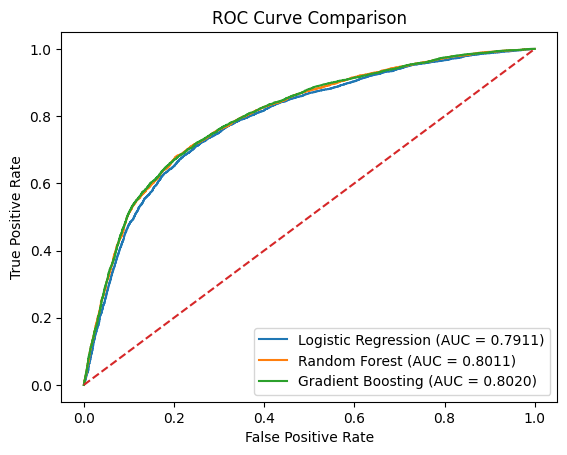

In [122]:
plt.figure()

for name, (model, X) in models.items():
    y_prob = model.predict_proba(X)[:,1]

    # False positive rate and True positive rate
    fpr, tpr, _ = roc_curve(Y_test, y_prob)

    # The AUC score
    auc = roc_auc_score(Y_test, y_prob)

    # Plotting everything, with 4 decimals for a better comparison
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

All three models exhibit very similar ROC curves and AUC scores.

- **Gradient Boosting** has the **highest AUC score**, 0.8020, indicating that it is the best overall at distinguishing between positive and negative cardiovascular cases
- **Random Forest** is not far behind, with an AUC score of 0.8011
- **Logistic Regression** is again the worst performing model of the three, with an AUC score of 0.7911

## **Confusion Matrix**

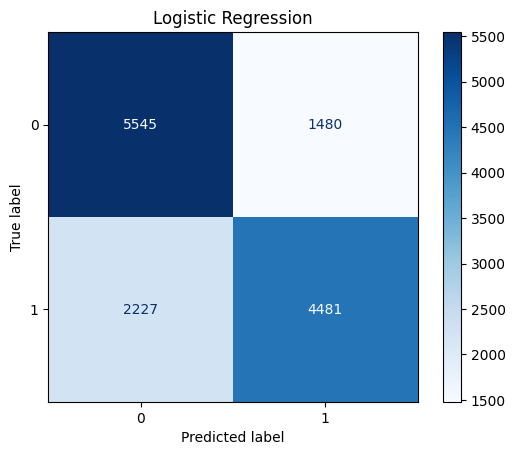

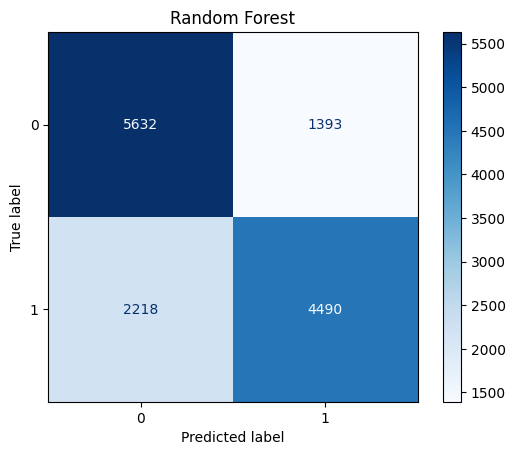

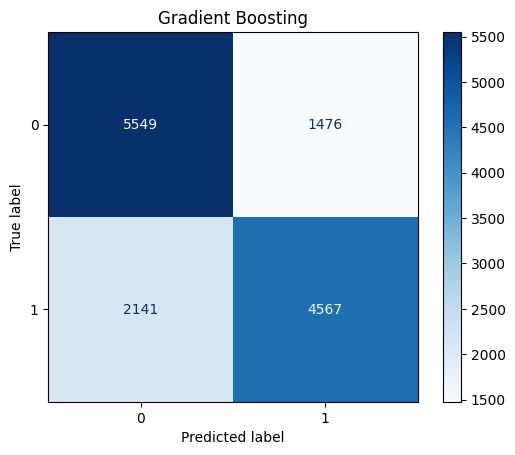

In [124]:
for name, (model, X) in models.items():
    ConfusionMatrixDisplay.from_estimator(
        model,
        X,
        Y_test,
        cmap="Blues"
    )

    plt.title(name)
    plt.show()

The confusion matrices show a similar distribution of predictions across the three models. All models correctly classify a large number of both positive and negative cases, which is consistent with their similar accuracy scores.

It is important to note that the **Gradient Boosting** model has the least amount of **false negatives**, with **2141** cases, compared to **2227** and **2218** for the Logistic Regression model and Random Forest model, respectively.

Although the difference is not that high, it is crucial that the model performs well in this aspect, as it could mean sending home a patient that actually is sick.

This result also aligns with the Gradient Boosting model having the highest Recall score.

## **Feature Importance**

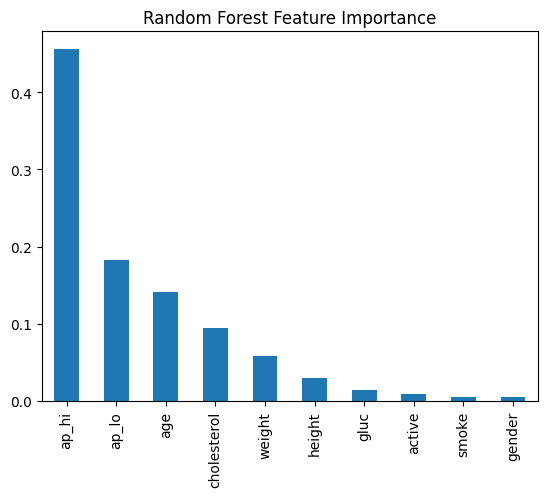

In [138]:
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

rf_importance.head(10).plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.show()

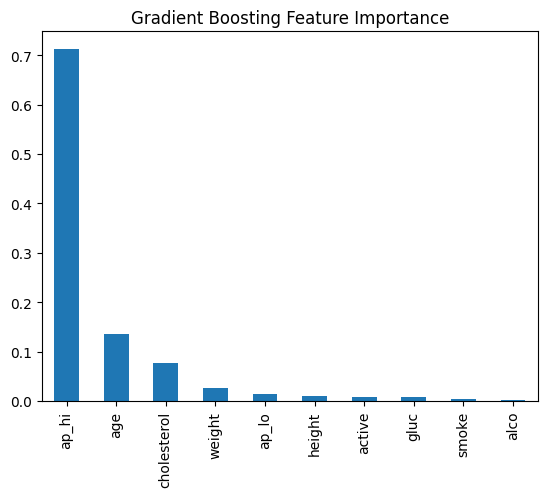

In [139]:
gb_importance = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

gb_importance.head(10).plot(kind="bar")
plt.title("Gradient Boosting Feature Importance")
plt.show()

The feature importance analysis shows that a few variables contribute greatly to the predictions. In both Random Forest and Gradient Boosting, **systolic blood pressure** (ap_hi) is the most influential feature by far.

In the **Random Forest model**, the distribution is less unbalanced, with other features like **diastolic blood pressure** (ap_lo), **age**, and **cholesterol** all contributing to a significant degree. This means that all of these variables play an important role in predicting cardiovascular risk.

On the other hand, the **Gradient Boosting model** relies heavily **ap_hi**, with **age** and **cholesterol** being the only other features that contribute to a noteworthy degree.

# Export for Visualization

In [147]:
rf_importance_df = rf_importance.reset_index()
rf_importance_df.columns = ["feature", "importance"]

rf_importance_df.to_csv("rf_feature_importance.csv", index=False)

In [148]:
gb_importance_df = gb_importance.reset_index()
gb_importance_df.columns = ["feature", "importance"]

gb_importance_df.to_csv("gb_feature_importance.csv", index=False)

In [154]:
rf = pd.read_csv("rf_feature_importance.csv")
rf["model"] = "Random Forest"

gb = pd.read_csv("gb_feature_importance.csv")
gb["model"] = "Gradient Boosting"

feature_importance = pd.concat([rf, gb])

feature_importance.to_csv("feature_importance.csv", index=False)

In [153]:
results_df.to_csv("model_comparison_metrics.csv")

In [150]:
predictions_df = X_test.copy()

predictions_df["actual"] = Y_test
predictions_df["rf_prediction"] = rf.predict(X_test)
predictions_df["gb_prediction"] = gb.predict(X_test)
predictions_df["lr_prediction"] = clf.predict(X_test_scaled)

predictions_df["rf_probability"] = rf.predict_proba(X_test)[:,1]
predictions_df["gb_probability"] = gb.predict_proba(X_test)[:,1]
predictions_df["lr_probability"] = clf.predict_proba(X_test_scaled)[:,1]

predictions_df.to_csv("model_predictions.csv", index=False)

# Conclusion

Overall, the three models achieved a very similar performance across most evaluation metrics. Random Forest obtained the highest accuracy and precision, while Gradient Boosting achieved the best recall, F1 score, and AUC. Logistic Regression performed slightly worse than the two tree-based models but still produced competitive results.

The feature engineering experiments showed that adding derived variables such as BMI and pulse pressure only resulted in a model performance improvement for Logistic Regression. The tree-based models performed best when using the original features, likely because they can already capture non-linear relationships between variables.

Considering the evaluation metrics and the importance of minimizing false negatives in medical prediction tasks, Gradient Boosting appears to be the most suitable model for this dataset, as it provides the best balance between identifying positive cardiovascular cases and maintaining strong overall predictive performance.